# Statistical Assessment of Heston Calibration Results

This notebook performs comprehensive statistical analysis of the calibration results for the Master's dissertation.

**Contents:**
1. Data Loading and Preparation
2. Descriptive Statistics
3. Hypothesis Testing
4. Effect Size Analysis
5. Confidence Intervals
6. Distribution Analysis
7. Correlation Analysis
8. Multiple Comparison Corrections
9. Bootstrap Analysis
10. Summary and Export

In [2]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import (
    ttest_rel, ttest_1samp, wilcoxon, shapiro, normaltest,
    jarque_bera, mannwhitneyu, levene, f_oneway
)
from statsmodels.stats.multitest import multipletests
import json
import warnings
warnings.filterwarnings('ignore')

# Add project root
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.heston_model import HestonModel

# Plotting settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.dpi'] = 150

# Directories
DATA_DIR = PROJECT_ROOT / 'data'
MODELS_DIR = DATA_DIR / 'models'
FIGURES_DIR = PROJECT_ROOT / 'results' / 'figures'
TABLES_DIR = PROJECT_ROOT / 'results' / 'tables'
STATS_DIR = PROJECT_ROOT / 'results' / 'statistics'

STATS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Data Loading and Preparation


In [3]:
# Load master results
master_file = MODELS_DIR / 'master_results.json'

if not master_file.exists():
    raise FileNotFoundError(f"Results not found: {master_file}\nPlease run calibration first: python main.py --tickers QQQ SPY TSLA")

with open(master_file) as f:
    master_results = json.load(f)

tickers = master_results['tickers']
results = master_results['results']

print(f"Loaded results for: {tickers}")
print(f"Timestamp: {master_results['timestamp']}\n")

# Load calibration data for individual option errors
calibration_data = {}
pricing_errors = {}

for ticker in tickers:
    # Load calibration data
    calib_file = DATA_DIR / 'processed' / 'calibration' / f'{ticker}_calibration.csv'
    if calib_file.exists():
        calibration_data[ticker] = pd.read_csv(calib_file)
        
        # Compute pricing errors
        S = calibration_data[ticker]['spot'].iloc[0]
        r = calibration_data[ticker]['r'].iloc[0] if 'r' in calibration_data[ticker].columns else 0.04
        market_prices = calibration_data[ticker]['mid_price'].values
        
        # Traditional method errors
        trad_params = results[ticker]['traditional']['params']
        trad_model = HestonModel(
            v0=trad_params['v0'], kappa=trad_params['kappa'], 
            theta=trad_params['theta'], sigma=trad_params['sigma'], 
            rho=trad_params['rho'], r=r
        )
        trad_prices = np.array([
            trad_model.call_price_fft(S, row['strike'], row['tau'])
            for _, row in calibration_data[ticker].iterrows()
        ])
        trad_errors = trad_prices - market_prices
        
        # NN method errors
        nn_params = results[ticker]['nn_surrogate']['params']
        nn_model = HestonModel(
            v0=nn_params['v0'], kappa=nn_params['kappa'],
            theta=nn_params['theta'], sigma=nn_params['sigma'],
            rho=nn_params['rho'], r=r
        )
        nn_prices = np.array([
            nn_model.call_price_fft(S, row['strike'], row['tau'])
            for _, row in calibration_data[ticker].iterrows()
        ])
        nn_errors = nn_prices - market_prices
        
        pricing_errors[ticker] = {
            'traditional': trad_errors,
            'nn_surrogate': nn_errors,
            'market_prices': market_prices,
            'moneyness': calibration_data[ticker]['moneyness'].values,
            'tau': calibration_data[ticker]['tau'].values
        }
        
        print(f"{ticker}: {len(calibration_data[ticker])} options loaded")

print("\nData preparation complete!")

Loaded results for: ['QQQ', 'SPY', 'TSLA']
Timestamp: 2025-11-28T19:29:55.191364

QQQ: 107 options loaded
SPY: 134 options loaded
TSLA: 47 options loaded

Data preparation complete!


## 2. Descriptive Statistics


In [4]:
# Create comprehensive descriptive statistics table
desc_stats = []

for ticker in tickers:
    r = results[ticker]
    errors = pricing_errors[ticker]
    
    # Traditional method
    trad_errors = errors['traditional']
    desc_stats.append({
        'Ticker': ticker,
        'Method': 'Traditional',
        'RMSE': r['traditional']['rmse'],
        'MAE': r['traditional']['mae'],
        'MAPE': r['traditional']['mape'],
        'Max Error': r['traditional']['max_error'],
        'Mean Error': np.mean(trad_errors),
        'Std Error': np.std(trad_errors),
        'Median Error': np.median(trad_errors),
        'Skewness': stats.skew(trad_errors),
        'Kurtosis': stats.kurtosis(trad_errors),
        'Time (s)': r['traditional']['time']
    })
    
    # NN method
    nn_errors = errors['nn_surrogate']
    desc_stats.append({
        'Ticker': ticker,
        'Method': 'NN Surrogate',
        'RMSE': r['nn_surrogate']['rmse'],
        'MAE': r['nn_surrogate']['mae'],
        'MAPE': r['nn_surrogate']['mape'],
        'Max Error': r['nn_surrogate']['max_error'],
        'Mean Error': np.mean(nn_errors),
        'Std Error': np.std(nn_errors),
        'Median Error': np.median(nn_errors),
        'Skewness': stats.skew(nn_errors),
        'Kurtosis': stats.kurtosis(nn_errors),
        'Time (s)': r['nn_surrogate']['time']
    })

desc_df = pd.DataFrame(desc_stats)
print("DESCRIPTIVE STATISTICS")
print("=" * 100)
print(desc_df.to_string(index=False))

# Save
desc_df.to_csv(TABLES_DIR / 'descriptive_statistics.csv', index=False)
desc_df.to_latex(TABLES_DIR / 'descriptive_statistics.tex', index=False, 
                 float_format='%.4f', caption='Descriptive Statistics',
                 label='tab:descriptive_stats')

DESCRIPTIVE STATISTICS
Ticker       Method     RMSE      MAE      MAPE  Max Error  Mean Error  Std Error  Median Error  Skewness  Kurtosis  Time (s)
   QQQ  Traditional 0.492300 0.375631  7.167588   1.772049    0.002396   0.492294     -0.113007  0.035594  0.980597  6.006934
   QQQ NN Surrogate 0.526355 0.422285  7.573092   1.943310   -0.133706   0.509089     -0.225428 -0.108322  0.881791  1.672622
   SPY  Traditional 0.552452 0.433466 10.675561   1.695277    0.017930   0.552161     -0.107076  0.035767  0.184474  5.335488
   SPY NN Surrogate 0.928245 0.750834 18.096114   2.484202   -0.652783   0.659935     -0.732174 -0.133204 -0.361265  2.223524
  TSLA  Traditional 0.737593 0.536094  1.931742   2.697099    0.063855   0.734823      0.148848  0.390616  2.271777  2.490578
  TSLA NN Surrogate 1.919167 1.288267  3.475575   4.568097   -1.170752   1.520704     -0.416491 -0.771701 -0.943632  3.064031


## 3. Hypothesis Testing

### 3.1 Paired t-tests for Pricing Accuracy


In [5]:
# Paired t-tests for absolute errors (paired by option)
hypothesis_tests = []

for ticker in tickers:
    errors = pricing_errors[ticker]
    trad_abs_errors = np.abs(errors['traditional'])
    nn_abs_errors = np.abs(errors['nn_surrogate'])
    
    # Paired t-test: H0: mean(trad) = mean(nn), H1: mean(trad) != mean(nn)
    t_stat, p_value = ttest_rel(trad_abs_errors, nn_abs_errors)
    
    # One-sample t-test: H0: mean(difference) = 0
    differences = nn_abs_errors - trad_abs_errors
    t_stat_diff, p_value_diff = ttest_1samp(differences, 0)
    
    # Effect size (Cohen's d for paired samples)
    mean_diff = np.mean(differences)
    std_diff = np.std(differences, ddof=1)
    cohens_d = mean_diff / std_diff if std_diff > 0 else 0
    
    hypothesis_tests.append({
        'Ticker': ticker,
        'Test': 'Paired t-test (Absolute Errors)',
        'T-statistic': t_stat,
        'P-value': p_value,
        'Mean Trad': np.mean(trad_abs_errors),
        'Mean NN': np.mean(nn_abs_errors),
        'Mean Difference': mean_diff,
        "Cohen's d": cohens_d,
        'Significant (α=0.05)': 'Yes' if p_value < 0.05 else 'No',
        'Significant (α=0.01)': 'Yes' if p_value < 0.01 else 'No'
    })

hypothesis_df = pd.DataFrame(hypothesis_tests)
print("HYPOTHESIS TESTS: Paired t-tests for Absolute Pricing Errors")
print("=" * 100)
print(hypothesis_df.to_string(index=False))

HYPOTHESIS TESTS: Paired t-tests for Absolute Pricing Errors
Ticker                            Test  T-statistic      P-value  Mean Trad  Mean NN  Mean Difference  Cohen's d Significant (α=0.05) Significant (α=0.01)
   QQQ Paired t-test (Absolute Errors)    -3.414316 9.070155e-04   0.375631 0.422285         0.046655   0.330074                  Yes                  Yes
   SPY Paired t-test (Absolute Errors)    -5.938380 2.370226e-08   0.433466 0.750834         0.317368   0.512998                  Yes                  Yes
  TSLA Paired t-test (Absolute Errors)    -3.701961 5.709413e-04   0.536094 1.288267         0.752173   0.539986                  Yes                  Yes


### 3.2 Wilcoxon Signed-Rank Test (Non-parametric)


In [6]:
# Wilcoxon signed-rank test (non-parametric alternative)
wilcoxon_tests = []

for ticker in tickers:
    errors = pricing_errors[ticker]
    trad_abs_errors = np.abs(errors['traditional'])
    nn_abs_errors = np.abs(errors['nn_surrogate'])
    
    # Wilcoxon signed-rank test
    try:
        w_stat, p_value = wilcoxon(trad_abs_errors, nn_abs_errors, alternative='two-sided')
    except ValueError:
        # If all differences are zero
        w_stat, p_value = 0, 1.0
    
    # Median difference
    differences = nn_abs_errors - trad_abs_errors
    median_diff = np.median(differences)
    
    wilcoxon_tests.append({
        'Ticker': ticker,
        'Test': 'Wilcoxon Signed-Rank',
        'W-statistic': w_stat,
        'P-value': p_value,
        'Median Trad': np.median(trad_abs_errors),
        'Median NN': np.median(nn_abs_errors),
        'Median Difference': median_diff,
        'Significant (α=0.05)': 'Yes' if p_value < 0.05 else 'No',
        'Significant (α=0.01)': 'Yes' if p_value < 0.01 else 'No'
    })

wilcoxon_df = pd.DataFrame(wilcoxon_tests)
print("HYPOTHESIS TESTS: Wilcoxon Signed-Rank Test (Non-parametric)")
print("=" * 100)
print(wilcoxon_df.to_string(index=False))

# Combine with previous tests
hypothesis_df = pd.concat([hypothesis_df, wilcoxon_df], ignore_index=True)

HYPOTHESIS TESTS: Wilcoxon Signed-Rank Test (Non-parametric)
Ticker                 Test  W-statistic      P-value  Median Trad  Median NN  Median Difference Significant (α=0.05) Significant (α=0.01)
   QQQ Wilcoxon Signed-Rank       1860.0 1.383152e-03     0.266069   0.362613           0.054057                  Yes                  Yes
   SPY Wilcoxon Signed-Rank       2096.0 7.093738e-08     0.338974   0.742614           0.520856                  Yes                  Yes
  TSLA Wilcoxon Signed-Rank        309.0 6.278256e-03     0.348022   0.543647           0.299126                  Yes                  Yes


### 3.3 Tests for Computational Time


In [7]:
# Test for time differences (paired by security)
time_tests = []

trad_times = [results[t]['traditional']['time'] for t in tickers]
nn_times = [results[t]['nn_surrogate']['time'] for t in tickers]

# Paired t-test
t_stat, p_value = ttest_rel(trad_times, nn_times)

# Wilcoxon
w_stat, p_value_w = wilcoxon(trad_times, nn_times, alternative='two-sided')

# Effect size
time_diffs = np.array(nn_times) - np.array(trad_times)
cohens_d = np.mean(time_diffs) / np.std(time_diffs, ddof=1) if np.std(time_diffs, ddof=1) > 0 else 0

time_tests.append({
    'Metric': 'Computational Time',
    'Test': 'Paired t-test',
    'T-statistic': t_stat,
    'P-value': p_value,
    'Mean Trad (s)': np.mean(trad_times),
    'Mean NN (s)': np.mean(nn_times),
    'Mean Difference (s)': np.mean(time_diffs),
    "Cohen's d": cohens_d,
    'Significant (α=0.05)': 'Yes' if p_value < 0.05 else 'No'
})

time_tests.append({
    'Metric': 'Computational Time',
    'Test': 'Wilcoxon Signed-Rank',
    'W-statistic': w_stat,
    'P-value': p_value_w,
    'Median Trad (s)': np.median(trad_times),
    'Median NN (s)': np.median(nn_times),
    'Median Difference (s)': np.median(time_diffs),
    "Cohen's d": cohens_d,
    'Significant (α=0.05)': 'Yes' if p_value_w < 0.05 else 'No'
})

time_df = pd.DataFrame(time_tests)
print("HYPOTHESIS TESTS: Computational Time")
print("=" * 100)
print(time_df.to_string(index=False))

HYPOTHESIS TESTS: Computational Time
            Metric                 Test  T-statistic  P-value  Mean Trad (s)  Mean NN (s)  Mean Difference (s)  Cohen's d Significant (α=0.05)  W-statistic  Median Trad (s)  Median NN (s)  Median Difference (s)
Computational Time        Paired t-test     1.553154 0.260595          4.611     2.320059            -2.290941  -0.896714                   No          NaN              NaN            NaN                    NaN
Computational Time Wilcoxon Signed-Rank          NaN 0.500000            NaN          NaN                  NaN  -0.896714                   No          1.0         5.335488       2.223524              -3.111964


## 4. Effect Size Analysis


In [8]:
# Comprehensive effect size analysis
effect_sizes = []

for ticker in tickers:
    errors = pricing_errors[ticker]
    trad_abs_errors = np.abs(errors['traditional'])
    nn_abs_errors = np.abs(errors['nn_surrogate'])
    
    # Cohen's d (paired samples)
    differences = nn_abs_errors - trad_abs_errors
    mean_diff = np.mean(differences)
    std_diff = np.std(differences, ddof=1)
    cohens_d = mean_diff / std_diff if std_diff > 0 else 0
    
    # Glass's delta (using pooled standard deviation)
    pooled_std = np.sqrt((np.var(trad_abs_errors, ddof=1) + np.var(nn_abs_errors, ddof=1)) / 2)
    glass_delta = (np.mean(nn_abs_errors) - np.mean(trad_abs_errors)) / pooled_std if pooled_std > 0 else 0
    
    # Hedges' g (bias-corrected)
    n = len(trad_abs_errors)
    correction_factor = 1 - (3 / (4 * n - 9))
    hedges_g = cohens_d * correction_factor
    
    # Percentage improvement
    pct_improvement = (np.mean(trad_abs_errors) - np.mean(nn_abs_errors)) / np.mean(trad_abs_errors) * 100
    
    effect_sizes.append({
        'Ticker': ticker,
        'Metric': 'Absolute Pricing Error',
        "Cohen's d": cohens_d,
        "Glass's Δ": glass_delta,
        "Hedges' g": hedges_g,
        'Mean Difference': mean_diff,
        'Percentage Change': pct_improvement,
        'Effect Size Interpretation': 
            'Large' if abs(cohens_d) >= 0.8 else ('Medium' if abs(cohens_d) >= 0.5 else 'Small')
    })

effect_df = pd.DataFrame(effect_sizes)
print("EFFECT SIZE ANALYSIS")
print("=" * 100)
print(effect_df.to_string(index=False))

# Save
effect_df.to_csv(TABLES_DIR / 'effect_sizes.csv', index=False)
effect_df.to_latex(TABLES_DIR / 'effect_sizes.tex', index=False, 
                   float_format='%.4f', caption='Effect Size Analysis',
                   label='tab:effect_sizes')

EFFECT SIZE ANALYSIS
Ticker                 Metric  Cohen's d  Glass's Δ  Hedges' g  Mean Difference  Percentage Change Effect Size Interpretation
   QQQ Absolute Pricing Error   0.330074   0.146850   0.327711         0.046655         -12.420348                      Small
   SPY Absolute Pricing Error   0.512998   0.693944   0.510078         0.317368         -73.216375                     Medium
  TSLA Absolute Pricing Error   0.539986   0.696906   0.530936         0.752173        -140.306077                     Medium


## 5. Confidence Intervals


In [9]:
# Bootstrap confidence intervals for mean differences
def bootstrap_ci(data, n_bootstrap=10000, confidence=0.95):
    """Compute bootstrap confidence interval for mean."""
    n = len(data)
    bootstrap_means = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=n, replace=True)
        bootstrap_means.append(np.mean(sample))
    bootstrap_means = np.array(bootstrap_means)
    alpha = 1 - confidence
    lower = np.percentile(bootstrap_means, 100 * alpha / 2)
    upper = np.percentile(bootstrap_means, 100 * (1 - alpha / 2))
    return lower, upper

confidence_intervals = []

for ticker in tickers:
    errors = pricing_errors[ticker]
    trad_abs_errors = np.abs(errors['traditional'])
    nn_abs_errors = np.abs(errors['nn_surrogate'])
    differences = nn_abs_errors - trad_abs_errors
    
    # Parametric CI (t-distribution)
    mean_diff = np.mean(differences)
    std_err = stats.sem(differences)
    t_crit = stats.t.ppf(0.975, len(differences) - 1)
    ci_lower_param = mean_diff - t_crit * std_err
    ci_upper_param = mean_diff + t_crit * std_err
    
    # Bootstrap CI
    ci_lower_boot, ci_upper_boot = bootstrap_ci(differences)
    
    confidence_intervals.append({
        'Ticker': ticker,
        'Metric': 'Mean Difference (NN - Trad)',
        'Mean': mean_diff,
        'Std Error': std_err,
        'CI Lower (Parametric)': ci_lower_param,
        'CI Upper (Parametric)': ci_upper_param,
        'CI Lower (Bootstrap)': ci_lower_boot,
        'CI Upper (Bootstrap)': ci_upper_boot,
        'Contains Zero': 'Yes' if (ci_lower_param <= 0 <= ci_upper_param) else 'No'
    })

ci_df = pd.DataFrame(confidence_intervals)
print("CONFIDENCE INTERVALS (95%) for Mean Differences")
print("=" * 100)
print(ci_df.to_string(index=False))

# Save
ci_df.to_csv(TABLES_DIR / 'confidence_intervals.csv', index=False)

CONFIDENCE INTERVALS (95%) for Mean Differences
Ticker                      Metric     Mean  Std Error  CI Lower (Parametric)  CI Upper (Parametric)  CI Lower (Bootstrap)  CI Upper (Bootstrap) Contains Zero
   QQQ Mean Difference (NN - Trad) 0.046655   0.013664               0.019564               0.073746              0.020185              0.073176            No
   SPY Mean Difference (NN - Trad) 0.317368   0.053444               0.211659               0.423078              0.212720              0.419948            No
  TSLA Mean Difference (NN - Trad) 0.752173   0.203182               0.343188               1.161157              0.372310              1.145571            No


## 6. Distribution Analysis


In [10]:
# Normality tests
normality_tests = []

for ticker in tickers:
    errors = pricing_errors[ticker]
    trad_abs_errors = np.abs(errors['traditional'])
    nn_abs_errors = np.abs(errors['nn_surrogate'])
    
    # Shapiro-Wilk test (for n < 5000)
    if len(trad_abs_errors) < 5000:
        shapiro_trad = shapiro(trad_abs_errors)
        shapiro_nn = shapiro(nn_abs_errors)
    else:
        shapiro_trad = (np.nan, np.nan)
        shapiro_nn = (np.nan, np.nan)
    
    # D'Agostino-Pearson normality test
    dagostino_trad = normaltest(trad_abs_errors)
    dagostino_nn = normaltest(nn_abs_errors)
    
    # Jarque-Bera test
    jb_trad = jarque_bera(trad_abs_errors)
    jb_nn = jarque_bera(nn_abs_errors)
    
    normality_tests.append({
        'Ticker': ticker,
        'Method': 'Traditional',
        'Shapiro-Wilk (stat)': shapiro_trad[0] if not np.isnan(shapiro_trad[0]) else np.nan,
        'Shapiro-Wilk (p)': shapiro_trad[1] if not np.isnan(shapiro_trad[1]) else np.nan,
        "D'Agostino-Pearson (stat)": dagostino_trad[0],
        "D'Agostino-Pearson (p)": dagostino_trad[1],
        'Jarque-Bera (stat)': jb_trad[0],
        'Jarque-Bera (p)': jb_trad[1],
        'Normal (α=0.05)': 'Yes' if dagostino_trad[1] > 0.05 else 'No'
    })
    
    normality_tests.append({
        'Ticker': ticker,
        'Method': 'NN Surrogate',
        'Shapiro-Wilk (stat)': shapiro_nn[0] if not np.isnan(shapiro_nn[0]) else np.nan,
        'Shapiro-Wilk (p)': shapiro_nn[1] if not np.isnan(shapiro_nn[1]) else np.nan,
        "D'Agostino-Pearson (stat)": dagostino_nn[0],
        "D'Agostino-Pearson (p)": dagostino_nn[1],
        'Jarque-Bera (stat)': jb_nn[0],
        'Jarque-Bera (p)': jb_nn[1],
        'Normal (α=0.05)': 'Yes' if dagostino_nn[1] > 0.05 else 'No'
    })

normality_df = pd.DataFrame(normality_tests)
print("NORMALITY TESTS")
print("=" * 100)
print(normality_df.to_string(index=False))

NORMALITY TESTS
Ticker       Method  Shapiro-Wilk (stat)  Shapiro-Wilk (p)  D'Agostino-Pearson (stat)  D'Agostino-Pearson (p)  Jarque-Bera (stat)  Jarque-Bera (p) Normal (α=0.05)
   QQQ  Traditional             0.843481      2.875617e-09                  36.957713            9.434841e-09           67.345434     2.377524e-15              No
   QQQ NN Surrogate             0.872011      3.812582e-08                  48.326151            3.207080e-11          133.461458     1.045232e-29              No
   SPY  Traditional             0.902572      7.412600e-08                  24.367780            5.112152e-06           31.018930     1.837913e-07              No
   SPY NN Surrogate             0.942471      2.376426e-05                   8.827745            1.210820e-02            9.402143     9.085538e-03              No
  TSLA  Traditional             0.812598      3.077239e-06                  32.709913            7.891011e-08           77.873945     1.229951e-17              No
  TSLA

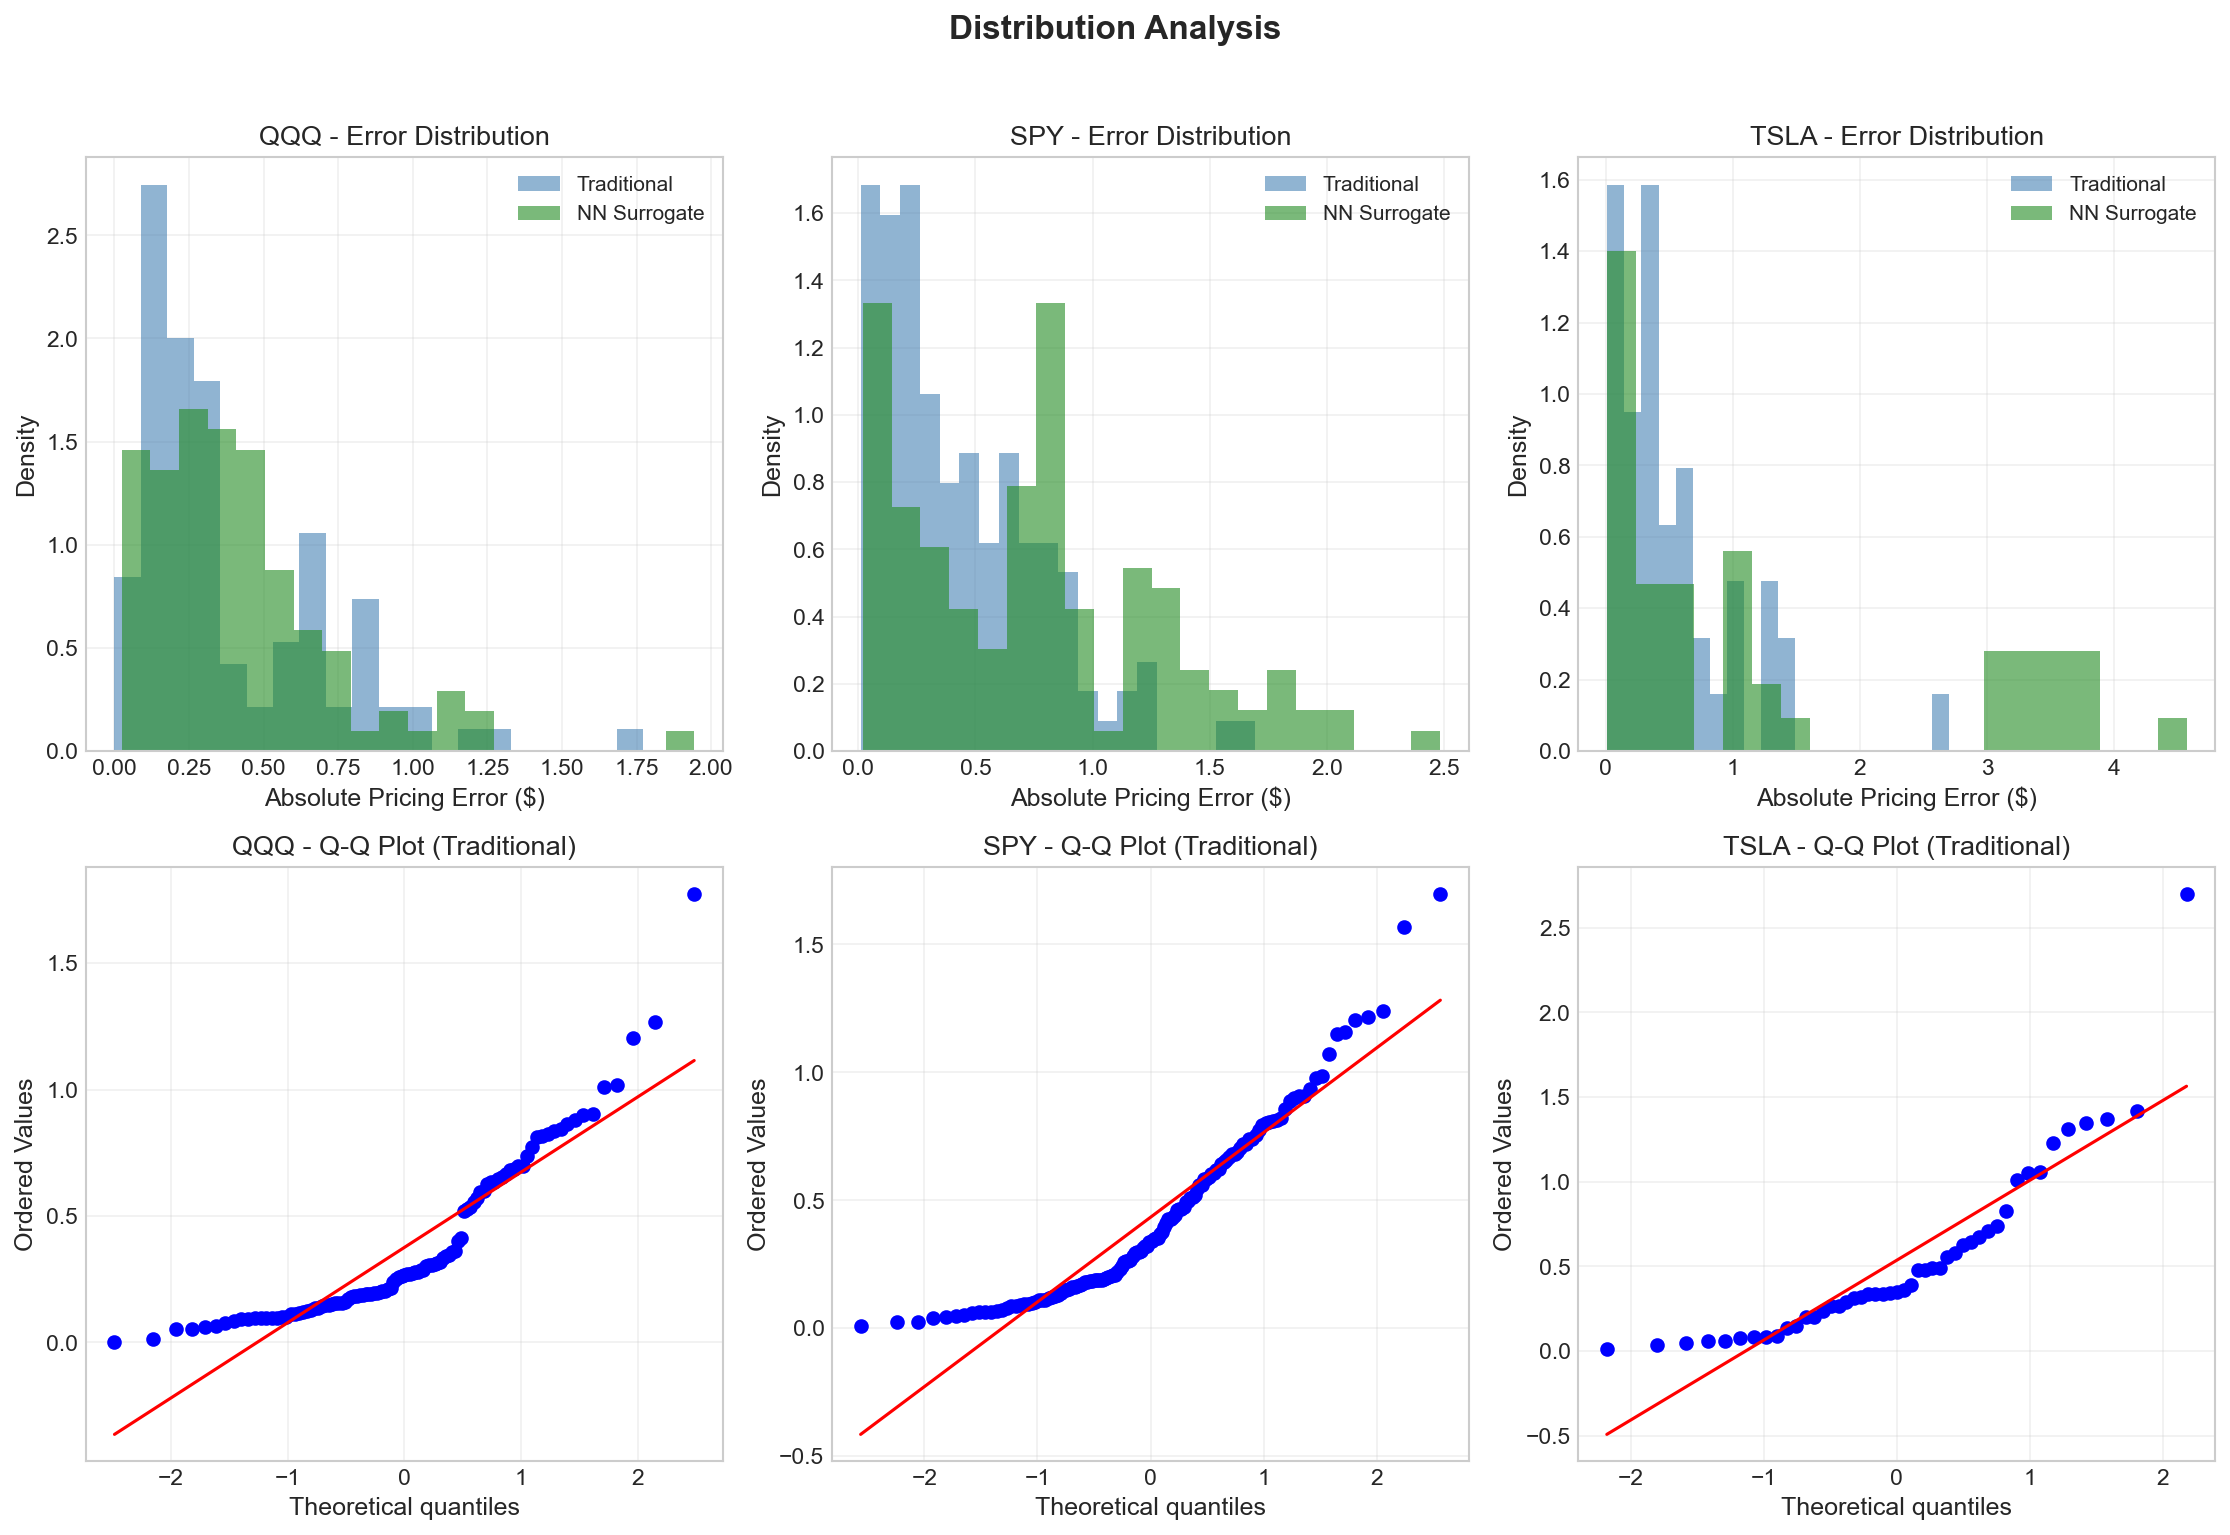

In [11]:
# Visualize distributions
fig, axes = plt.subplots(2, len(tickers), figsize=(5*len(tickers), 10))

for col, ticker in enumerate(tickers):
    errors = pricing_errors[ticker]
    trad_abs_errors = np.abs(errors['traditional'])
    nn_abs_errors = np.abs(errors['nn_surrogate'])
    
    # Histogram
    ax = axes[0, col]
    ax.hist(trad_abs_errors, bins=20, alpha=0.6, label='Traditional', density=True, color='steelblue')
    ax.hist(nn_abs_errors, bins=20, alpha=0.6, label='NN Surrogate', density=True, color='forestgreen')
    ax.set_xlabel('Absolute Pricing Error ($)')
    ax.set_ylabel('Density')
    ax.set_title(f'{ticker} - Error Distribution')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Q-Q plot
    ax = axes[1, col]
    stats.probplot(trad_abs_errors, dist="norm", plot=ax)
    ax.set_title(f'{ticker} - Q-Q Plot (Traditional)')
    ax.grid(True, alpha=0.3)

plt.suptitle('Distribution Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'distribution_analysis.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGURES_DIR / 'distribution_analysis.pdf', bbox_inches='tight')
plt.show()

## 7. Correlation Analysis


In [12]:
# Correlation between errors and option characteristics
correlation_analysis = []

for ticker in tickers:
    errors = pricing_errors[ticker]
    trad_abs_errors = np.abs(errors['traditional'])
    nn_abs_errors = np.abs(errors['nn_surrogate'])
    moneyness = errors['moneyness']
    tau = errors['tau']
    market_prices = errors['market_prices']
    
    # Pearson correlations
    trad_moneyness_r, trad_moneyness_p = stats.pearsonr(trad_abs_errors, moneyness)
    trad_tau_r, trad_tau_p = stats.pearsonr(trad_abs_errors, tau)
    trad_price_r, trad_price_p = stats.pearsonr(trad_abs_errors, market_prices)
    
    nn_moneyness_r, nn_moneyness_p = stats.pearsonr(nn_abs_errors, moneyness)
    nn_tau_r, nn_tau_p = stats.pearsonr(nn_abs_errors, tau)
    nn_price_r, nn_price_p = stats.pearsonr(nn_abs_errors, market_prices)
    
    # Spearman correlations (non-parametric)
    trad_moneyness_rho, trad_moneyness_p_rho = stats.spearmanr(trad_abs_errors, moneyness)
    trad_tau_rho, trad_tau_p_rho = stats.spearmanr(trad_abs_errors, tau)
    
    nn_moneyness_rho, nn_moneyness_p_rho = stats.spearmanr(nn_abs_errors, moneyness)
    nn_tau_rho, nn_tau_p_rho = stats.spearmanr(nn_abs_errors, tau)
    
    correlation_analysis.append({
        'Ticker': ticker,
        'Method': 'Traditional',
        'Moneyness (Pearson r)': trad_moneyness_r,
        'Moneyness (p)': trad_moneyness_p,
        'Moneyness (Spearman ρ)': trad_moneyness_rho,
        'Maturity (Pearson r)': trad_tau_r,
        'Maturity (p)': trad_tau_p,
        'Maturity (Spearman ρ)': trad_tau_rho,
        'Price (Pearson r)': trad_price_r,
        'Price (p)': trad_price_p
    })
    
    correlation_analysis.append({
        'Ticker': ticker,
        'Method': 'NN Surrogate',
        'Moneyness (Pearson r)': nn_moneyness_r,
        'Moneyness (p)': nn_moneyness_p,
        'Moneyness (Spearman ρ)': nn_moneyness_rho,
        'Maturity (Pearson r)': nn_tau_r,
        'Maturity (p)': nn_tau_p,
        'Maturity (Spearman ρ)': nn_tau_rho,
        'Price (Pearson r)': nn_price_r,
        'Price (p)': nn_price_p
    })

corr_df = pd.DataFrame(correlation_analysis)
print("CORRELATION ANALYSIS")
print("=" * 100)
print(corr_df.to_string(index=False))

# Save
corr_df.to_csv(TABLES_DIR / 'correlation_analysis.csv', index=False)

CORRELATION ANALYSIS
Ticker       Method  Moneyness (Pearson r)  Moneyness (p)  Moneyness (Spearman ρ)  Maturity (Pearson r)  Maturity (p)  Maturity (Spearman ρ)  Price (Pearson r)    Price (p)
   QQQ  Traditional              -0.276256       0.003973               -0.316269              0.188928  5.130511e-02              -0.015765           0.319361 7.995633e-04
   QQQ NN Surrogate              -0.261411       0.006533               -0.261485              0.237283  1.385912e-02               0.178464           0.364949 1.111321e-04
   SPY  Traditional              -0.194203       0.024547               -0.270712              0.419498  4.528860e-07               0.332375           0.462654 1.821821e-08
   SPY NN Surrogate               0.043119       0.620817                0.076017              0.263451  2.100643e-03               0.475273           0.174348 4.392865e-02
  TSLA  Traditional              -0.164311       0.269744               -0.049001              0.590054  1.271296e

## 8. Multiple Comparison Corrections


In [13]:
# Collect all p-values for multiple comparison correction
all_p_values = []
test_names = []

# P-values from paired t-tests
for ticker in tickers:
    errors = pricing_errors[ticker]
    trad_abs_errors = np.abs(errors['traditional'])
    nn_abs_errors = np.abs(errors['nn_surrogate'])
    _, p_value = ttest_rel(trad_abs_errors, nn_abs_errors)
    all_p_values.append(p_value)
    test_names.append(f'{ticker} - Paired t-test (Errors)')

# P-values from Wilcoxon tests
for ticker in tickers:
    errors = pricing_errors[ticker]
    trad_abs_errors = np.abs(errors['traditional'])
    nn_abs_errors = np.abs(errors['nn_surrogate'])
    try:
        _, p_value = wilcoxon(trad_abs_errors, nn_abs_errors)
    except ValueError:
        p_value = 1.0
    all_p_values.append(p_value)
    test_names.append(f'{ticker} - Wilcoxon (Errors)')

# Apply multiple comparison corrections
rejected_bonf, p_corrected_bonf, _, _ = multipletests(
    all_p_values, alpha=0.05, method='bonferroni'
)

rejected_fdr, p_corrected_fdr, _, _ = multipletests(
    all_p_values, alpha=0.05, method='fdr_bh'
)

# Create correction table
correction_df = pd.DataFrame({
    'Test': test_names,
    'Original P-value': all_p_values,
    'Bonferroni Corrected': p_corrected_bonf,
    'Bonferroni Significant': rejected_bonf,
    'FDR (Benjamini-Hochberg)': p_corrected_fdr,
    'FDR Significant': rejected_fdr
})

print("MULTIPLE COMPARISON CORRECTIONS")
print("=" * 100)
print(correction_df.to_string(index=False))

# Save
correction_df.to_csv(TABLES_DIR / 'multiple_comparison_corrections.csv', index=False)

MULTIPLE COMPARISON CORRECTIONS
                         Test  Original P-value  Bonferroni Corrected  Bonferroni Significant  FDR (Benjamini-Hochberg)  FDR Significant
 QQQ - Paired t-test (Errors)      9.070155e-04          5.442093e-03                    True              1.360523e-03             True
 SPY - Paired t-test (Errors)      2.370226e-08          1.422136e-07                    True              1.422136e-07             True
TSLA - Paired t-test (Errors)      5.709413e-04          3.425648e-03                    True              1.141883e-03             True
      QQQ - Wilcoxon (Errors)      1.383152e-03          8.298915e-03                    True              1.659783e-03             True
      SPY - Wilcoxon (Errors)      7.093738e-08          4.256243e-07                    True              2.128122e-07             True
     TSLA - Wilcoxon (Errors)      6.278256e-03          3.766954e-02                    True              6.278256e-03             True


## 9. Bootstrap Analysis


In [14]:
# Bootstrap analysis for RMSE, MAE, and speedup
def bootstrap_statistic(data, statistic_func, n_bootstrap=10000, confidence=0.95):
    """Bootstrap confidence interval for any statistic."""
    n = len(data)
    bootstrap_stats = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=n, replace=True)
        bootstrap_stats.append(statistic_func(sample))
    bootstrap_stats = np.array(bootstrap_stats)
    alpha = 1 - confidence
    lower = np.percentile(bootstrap_stats, 100 * alpha / 2)
    upper = np.percentile(bootstrap_stats, 100 * (1 - alpha / 2))
    mean_boot = np.mean(bootstrap_stats)
    return mean_boot, lower, upper

bootstrap_results = []

# Bootstrap for aggregated metrics across securities
trad_rmses = [results[t]['traditional']['rmse'] for t in tickers]
nn_rmses = [results[t]['nn_surrogate']['rmse'] for t in tickers]
speedups = [results[t]['speedup'] for t in tickers]

# Bootstrap mean RMSE
trad_rmse_mean, trad_rmse_lower, trad_rmse_upper = bootstrap_statistic(
    trad_rmses, np.mean, n_bootstrap=10000
)
nn_rmse_mean, nn_rmse_lower, nn_rmse_upper = bootstrap_statistic(
    nn_rmses, np.mean, n_bootstrap=10000
)

# Bootstrap mean speedup
speedup_mean, speedup_lower, speedup_upper = bootstrap_statistic(
    speedups, np.mean, n_bootstrap=10000
)

bootstrap_results.append({
    'Metric': 'Mean RMSE (Traditional)',
    'Bootstrap Mean': trad_rmse_mean,
    'CI Lower (95%)': trad_rmse_lower,
    'CI Upper (95%)': trad_rmse_upper,
    'Sample Mean': np.mean(trad_rmses)
})

bootstrap_results.append({
    'Metric': 'Mean RMSE (NN)',
    'Bootstrap Mean': nn_rmse_mean,
    'CI Lower (95%)': nn_rmse_lower,
    'CI Upper (95%)': nn_rmse_upper,
    'Sample Mean': np.mean(nn_rmses)
})

bootstrap_results.append({
    'Metric': 'Mean Speedup',
    'Bootstrap Mean': speedup_mean,
    'CI Lower (95%)': speedup_lower,
    'CI Upper (95%)': speedup_upper,
    'Sample Mean': np.mean(speedups)
})

bootstrap_df = pd.DataFrame(bootstrap_results)
print("BOOTSTRAP ANALYSIS (10,000 iterations)")
print("=" * 100)
print(bootstrap_df.to_string(index=False))

# Save
bootstrap_df.to_csv(TABLES_DIR / 'bootstrap_analysis.csv', index=False)

BOOTSTRAP ANALYSIS (10,000 iterations)
                 Metric  Bootstrap Mean  CI Lower (95%)  CI Upper (95%)  Sample Mean
Mean RMSE (Traditional)        0.593797        0.492300        0.737593     0.594115
         Mean RMSE (NN)        1.121309        0.526355        1.919167     1.124589
           Mean Speedup        2.265065        0.812844        3.591328     2.267912


## 10. Summary and Export


In [15]:
# Create comprehensive statistical summary
statistical_summary = {
    'timestamp': master_results['timestamp'] if 'timestamp' in master_results else None,
    'tickers': tickers,
    'n_securities': len(tickers),
    'total_options': sum([len(pricing_errors[t]['traditional']) for t in tickers]),
    'hypothesis_tests': {
        'significant_at_0_05': sum([1 for _, row in hypothesis_df.iterrows() if row['P-value'] < 0.05]),
        'significant_at_0_01': sum([1 for _, row in hypothesis_df.iterrows() if row['P-value'] < 0.01]),
        'total_tests': len(hypothesis_df)
    },
    'effect_sizes': {
        'large_effects': sum([1 for _, row in effect_df.iterrows() if abs(row["Cohen's d"]) >= 0.8]),
        'medium_effects': sum([1 for _, row in effect_df.iterrows() if 0.5 <= abs(row["Cohen's d"]) < 0.8]),
        'small_effects': sum([1 for _, row in effect_df.iterrows() if abs(row["Cohen's d"]) < 0.5])
    },
    'normality': {
        'normal_distributions': sum([1 for _, row in normality_df.iterrows() if row['Normal (α=0.05)'] == 'Yes']),
        'non_normal_distributions': sum([1 for _, row in normality_df.iterrows() if row['Normal (α=0.05)'] == 'No'])
    },
    'aggregate_metrics': {
        'mean_rmse_traditional': np.mean([results[t]['traditional']['rmse'] for t in tickers]),
        'mean_rmse_nn': np.mean([results[t]['nn_surrogate']['rmse'] for t in tickers]),
        'mean_speedup': np.mean([results[t]['speedup'] for t in tickers]),
        'mean_time_traditional': np.mean([results[t]['traditional']['time'] for t in tickers]),
        'mean_time_nn': np.mean([results[t]['nn_surrogate']['time'] for t in tickers])
    }
}

# Save summary
with open(STATS_DIR / 'statistical_summary.json', 'w') as f:
    json.dump(statistical_summary, f, indent=2)

print("\n" + "=" * 100)
print("STATISTICAL ASSESSMENT SUMMARY")
print("=" * 100)
print(f"\nSecurities Analyzed: {statistical_summary['n_securities']}")
print(f"Total Options: {statistical_summary['total_options']}")
print(f"\nHypothesis Tests:")
print(f"  - Significant at α=0.05: {statistical_summary['hypothesis_tests']['significant_at_0_05']}/{statistical_summary['hypothesis_tests']['total_tests']}")
print(f"  - Significant at α=0.01: {statistical_summary['hypothesis_tests']['significant_at_0_01']}/{statistical_summary['hypothesis_tests']['total_tests']}")
print(f"\nEffect Sizes:")
print(f"  - Large (|d| ≥ 0.8): {statistical_summary['effect_sizes']['large_effects']}")
print(f"  - Medium (0.5 ≤ |d| < 0.8): {statistical_summary['effect_sizes']['medium_effects']}")
print(f"  - Small (|d| < 0.5): {statistical_summary['effect_sizes']['small_effects']}")
print(f"\nNormality Tests:")
print(f"  - Normal distributions: {statistical_summary['normality']['normal_distributions']}")
print(f"  - Non-normal distributions: {statistical_summary['normality']['non_normal_distributions']}")
print(f"\nAggregate Performance:")
print(f"  - Mean RMSE (Traditional): ${statistical_summary['aggregate_metrics']['mean_rmse_traditional']:.4f}")
print(f"  - Mean RMSE (NN): ${statistical_summary['aggregate_metrics']['mean_rmse_nn']:.4f}")
print(f"  - Mean Speedup: {statistical_summary['aggregate_metrics']['mean_speedup']:.2f}x")
print(f"  - Mean Time (Traditional): {statistical_summary['aggregate_metrics']['mean_time_traditional']:.2f}s")
print(f"  - Mean Time (NN): {statistical_summary['aggregate_metrics']['mean_time_nn']:.2f}s")

print(f"\n\nAll results saved to:")
print(f"  - Tables: {TABLES_DIR}")
print(f"  - Statistics: {STATS_DIR}")
print(f"  - Figures: {FIGURES_DIR}")


STATISTICAL ASSESSMENT SUMMARY

Securities Analyzed: 3
Total Options: 288

Hypothesis Tests:
  - Significant at α=0.05: 6/6
  - Significant at α=0.01: 6/6

Effect Sizes:
  - Large (|d| ≥ 0.8): 0
  - Medium (0.5 ≤ |d| < 0.8): 2
  - Small (|d| < 0.5): 1

Normality Tests:
  - Normal distributions: 0
  - Non-normal distributions: 6

Aggregate Performance:
  - Mean RMSE (Traditional): $0.5941
  - Mean RMSE (NN): $1.1246
  - Mean Speedup: 2.27x
  - Mean Time (Traditional): 4.61s
  - Mean Time (NN): 2.32s


All results saved to:
  - Tables: /Users/jorismrvy/Desktop/TBS MSc/Master Dissertation/Heston Model/results/tables
  - Statistics: /Users/jorismrvy/Desktop/TBS MSc/Master Dissertation/Heston Model/results/statistics
  - Figures: /Users/jorismrvy/Desktop/TBS MSc/Master Dissertation/Heston Model/results/figures
